# Attention

In [1]:
import torch
import torch.nn
import torch.nn.functional as F
from dataclasses import dataclass
import math

torch.manual_seed(42)

In [2]:
@dataclass
class ModelConfig:
    num_hidden_layers: int = 4
    num_experts: int = 8
    experts_per_token: int = 4
    vocab_size: int = 100
    hidden_size: int = 288
    intermediate_size: int = 288
    swiglu_limit: float = 7.0
    head_dim: int = 64
    num_attention_heads: int = 8
    num_key_value_heads: int = 2
    sliding_window: int = 32
    initial_context_length: int = 4096
    rope_theta: float = 150000.0
    rope_scaling_factor: float = 32.0
    rope_ntk_alpha: float = 1.0
    rope_ntk_beta: float = 32.0

config = ModelConfig()

In [3]:


class RMSNorm(torch.nn.Module):
    def __init__(
        self, num_features: int, eps: float = 1e-05, device: torch.device | None = None
    ):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.scale = torch.nn.Parameter(
            torch.ones(num_features, device=device, dtype=torch.float32)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-1] == self.num_features
        t, dtype = x.float(), x.dtype
        t = t * torch.rsqrt(torch.mean(t**2, dim=-1, keepdim=True) + self.eps)
        return (t * self.scale).to(dtype)

In [4]:


def sdpa(Q, K, V, S, sm_scale, sliding_window=0):
    # sliding_window == 0 means no sliding window
    n_tokens, n_heads, q_mult, d_head = Q.shape
    assert K.shape == (n_tokens, n_heads, d_head)
    assert V.shape == (n_tokens, n_heads, d_head)
    K = K[:, :, None, :].expand(-1, -1, q_mult, -1)
    V = V[:, :, None, :].expand(-1, -1, q_mult, -1)
    S = S.reshape(n_heads, q_mult, 1, 1).expand(-1, -1, n_tokens, -1)
    mask = torch.triu(Q.new_full((n_tokens, n_tokens), -float("inf")), diagonal=1)
    if sliding_window > 0:
        mask += torch.tril(
            mask.new_full((n_tokens, n_tokens), -float("inf")), diagonal=-sliding_window
        )
    QK = torch.einsum("qhmd,khmd->hmqk", Q, K)
    QK *= sm_scale
    QK += mask[None, None, :, :]
    QK = torch.cat([QK, S], dim=-1)
    W = torch.softmax(QK, dim=-1)
    W = W[..., :-1]
    attn = torch.einsum("hmqk,khmd->qhmd", W, V)
    return attn.reshape(n_tokens, -1)

class AttentionBlock(torch.nn.Module):
    def __init__(
        self,
        config: ModelConfig,
        layer_idx: int = 0,
        device: torch.device | None = None,
    ):
        super().__init__()
        self.head_dim = config.head_dim
        self.num_attention_heads = config.num_attention_heads
        self.num_key_value_heads = config.num_key_value_heads
        # Only apply sliding window to every other layer
        self.sliding_window = config.sliding_window if layer_idx % 2 == 0 else 0
        self.sinks = torch.nn.Parameter(
            torch.empty(config.num_attention_heads, device=device, 
                        # dtype=torch.bfloat16
                       )
        )
        self.norm = RMSNorm(config.hidden_size, device=device)
        qkv_dim = config.head_dim * (
            config.num_attention_heads + 2 * config.num_key_value_heads
        )
        self.qkv = torch.nn.Linear(
            config.hidden_size, qkv_dim, device=device, 
            # dtype=torch.bfloat16
        )
        self.out = torch.nn.Linear(
            config.head_dim * config.num_attention_heads,
            config.hidden_size,
            device=device,
            # dtype=torch.bfloat16,
        )
        self.sm_scale = 1 / math.sqrt(config.head_dim)
        # self.rope = RotaryEmbedding(
        #     config.head_dim,
        #     config.rope_theta,
        #     torch.float32,
        #     initial_context_length=config.initial_context_length,
        #     scaling_factor=config.rope_scaling_factor,
        #     ntk_alpha=config.rope_ntk_alpha,
        #     ntk_beta=config.rope_ntk_beta,
        #     device=device,
        # )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        t = self.norm(x)
        qkv = self.qkv(t)
        q = qkv[:, : self.num_attention_heads * self.head_dim].contiguous()
        k = qkv[
            :,
            self.num_attention_heads
            * self.head_dim : (self.num_attention_heads + self.num_key_value_heads)
            * self.head_dim,
        ].contiguous()
        v = qkv[
            :,
            (self.num_attention_heads + self.num_key_value_heads)
            * self.head_dim : (self.num_attention_heads + 2 * self.num_key_value_heads)
            * self.head_dim,
        ].contiguous()

        q = q.view(
            -1,
            self.num_key_value_heads,
            self.num_attention_heads // self.num_key_value_heads,
            self.head_dim,
        )
        k = k.view(-1, self.num_key_value_heads, self.head_dim)
        v = v.view(-1, self.num_key_value_heads, self.head_dim)
        # q, k = self.rope(q, k)
        t = sdpa(q, k, v, self.sinks, self.sm_scale, self.sliding_window)
        t = self.out(t)
        t = x + t
        return t

In [5]:
model = AttentionBlock(config,  layer_idx = 1)
print(model)

AttentionBlock(
  (norm): RMSNorm()
  (qkv): Linear(in_features=288, out_features=768, bias=True)
  (out): Linear(in_features=512, out_features=288, bias=True)
)


In [6]:
print(config.num_attention_heads)
print(model.sinks)

8
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)


### Attn: multi-head

In [13]:
# x = torch.randn(1, 512, config.hidden_size)
x = torch.randn(512, config.hidden_size)

In [14]:
t = model.norm(x)
print('t.shape:', t.shape) 
qkv = model.qkv(t)
print('qkv.shape:', qkv.shape) 
q = qkv[:, : model.num_attention_heads * model.head_dim].contiguous()
print('q.shape:', q.shape) 

k = qkv[
    :,
    model.num_attention_heads
    * model.head_dim : (model.num_attention_heads + model.num_key_value_heads)
    * model.head_dim,
].contiguous()
print('k.shape:', k.shape) 

v = qkv[
    :,
    (model.num_attention_heads + model.num_key_value_heads)
    * model.head_dim : (model.num_attention_heads + 2 * model.num_key_value_heads)
    * model.head_dim,
].contiguous()
print('v.shape:', v.shape) 

q = q.view(
    -1,
    model.num_key_value_heads,
    model.num_attention_heads // model.num_key_value_heads,
    model.head_dim,
)
print('multi head q.shape:', q.shape) 
k = k.view(-1, model.num_key_value_heads, model.head_dim)
v = v.view(-1, model.num_key_value_heads, model.head_dim)
print('multi head k.shape:', k.shape) 
print('multi head v.shape:', v.shape) 

t.shape: torch.Size([512, 288])
qkv.shape: torch.Size([512, 768])
q.shape: torch.Size([512, 512])
k.shape: torch.Size([512, 128])
v.shape: torch.Size([512, 128])
multi head q.shape: torch.Size([512, 2, 4, 64])
multi head k.shape: torch.Size([512, 2, 64])
multi head v.shape: torch.Size([512, 2, 64])


# sdpa

In [23]:
Q = q
K = k
V = v
S = model.sinks
sm_scale = 1 / math.sqrt(config.head_dim)
sliding_window = 1
print('sink shape:', S.shape)

# sliding_window == 0 means no sliding window
n_tokens, n_heads, q_mult, d_head = Q.shape # seq_len, 2个组, 每组4个q head, d_head:头维度
print(Q.shape)
assert K.shape == (n_tokens, n_heads, d_head)
assert V.shape == (n_tokens, n_heads, d_head)
K = K[:, :, None, :].expand(-1, -1, q_mult, -1)
V = V[:, :, None, :].expand(-1, -1, q_mult, -1)
S = S.reshape(n_heads, q_mult, 1, 1).expand(-1, -1, n_tokens, -1)
print('sink reshape', S.shape) # 每个 token 都有一个 sink, 实际上就是一个 可学习的因子 $ exp(x) / sum(exp(x)) + sink $ 

mask = torch.triu(Q.new_full((n_tokens, n_tokens), -float("inf")), diagonal=1)
print('mask.shape', mask.shape) # 512, 512, 不考虑 padding

if sliding_window > 0:
    mask += torch.tril(
        mask.new_full((n_tokens, n_tokens), -float("inf")), diagonal=-sliding_window
    )
    
QK = torch.einsum("qhmd,khmd->hmqk", Q, K)
print('attention score:', QK.shape)
QK *= sm_scale
QK += mask[None, None, :, :]
QK = torch.cat([QK, S], dim=-1)
print('attention score sink:', QK.shape)


W = torch.softmax(QK, dim=-1)
W = W[..., :-1] # 仅用于处理 softmax, 而不会做后续的 特征加权组合

attn = torch.einsum("hmqk,khmd->qhmd", W, V)
result = attn.reshape(n_tokens, -1)
print(result.shape)
# return attn.reshape(n_tokens, -1)

sink shape: torch.Size([8])
torch.Size([512, 2, 4, 64])
sink reshape torch.Size([2, 4, 512, 1])
mask.shape torch.Size([512, 512])
attention score: torch.Size([2, 4, 512, 512])
attention score sink: torch.Size([2, 4, 512, 513])
torch.Size([512, 512])


In [27]:
print(Q.new_full((n_tokens, n_tokens), -float("inf")))
print(torch.triu(Q.new_full((n_tokens, n_tokens), -float("inf")), diagonal=1))

tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf],
        [-inf, -inf, -inf,  ..., -inf, -inf, -inf],
        [-inf, -inf, -inf,  ..., -inf, -inf, -inf],
        ...,
        [-inf, -inf, -inf,  ..., -inf, -inf, -inf],
        [-inf, -inf, -inf,  ..., -inf, -inf, -inf],
        [-inf, -inf, -inf,  ..., -inf, -inf, -inf]])
tensor([[0., -inf, -inf,  ..., -inf, -inf, -inf],
        [0., 0., -inf,  ..., -inf, -inf, -inf],
        [0., 0., 0.,  ..., -inf, -inf, -inf],
        ...,
        [0., 0., 0.,  ..., 0., -inf, -inf],
        [0., 0., 0.,  ..., 0., 0., -inf],
        [0., 0., 0.,  ..., 0., 0., 0.]])


In [132]:

torch.tril(
        mask.new_full((n_tokens, n_tokens), -float("inf")), diagonal=-1
    )

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [-inf, 0., 0.,  ..., 0., 0., 0.],
        [-inf, -inf, 0.,  ..., 0., 0., 0.],
        ...,
        [-inf, -inf, -inf,  ..., 0., 0., 0.],
        [-inf, -inf, -inf,  ..., -inf, 0., 0.],
        [-inf, -inf, -inf,  ..., -inf, -inf, 0.]])

In [59]:
torch.triu(
    Q.new_full((n_tokens, n_tokens), -float("inf")), diagonal=1) + torch.tril(
        mask.new_full((n_tokens, n_tokens), -float("inf")), diagonal=-2
    )

tensor([[0., -inf, -inf,  ..., -inf, -inf, -inf],
        [0., 0., -inf,  ..., -inf, -inf, -inf],
        [-inf, 0., 0.,  ..., -inf, -inf, -inf],
        ...,
        [-inf, -inf, -inf,  ..., 0., -inf, -inf],
        [-inf, -inf, -inf,  ..., 0., 0., -inf],
        [-inf, -inf, -inf,  ..., -inf, 0., 0.]])

In [32]:
a = torch.randn(2,3)
print(a[None, None, :, :].shape)

torch.Size([1, 1, 2, 3])


# MLP

In [39]:
def swiglu(x, alpha: float = 1.702, limit: float = 7.0):
    x_glu, x_linear = x[..., ::2], x[..., 1::2]
    # Clamp the input values
    x_glu = x_glu.clamp(min=None, max=limit)
    x_linear = x_linear.clamp(min=-limit, max=limit)
    out_glu = x_glu * torch.sigmoid(alpha * x_glu)
    # Note we add an extra bias of 1 to the linear layer
    return out_glu * (x_linear + 1)

In [42]:
# 可以忽略这个代码，跳过测试debug版本

class MLPBlock(torch.nn.Module):
    def __init__(
        self,
        config: ModelConfig,
        device: torch.device | None = None,
    ):
        super().__init__()
        self.num_experts = config.num_experts
        self.experts_per_token = config.experts_per_token
        self.swiglu_limit = config.swiglu_limit
        self.world_size = 1
        self.norm = RMSNorm(config.hidden_size, device=device)
        self.gate = torch.nn.Linear(
            config.hidden_size, config.num_experts, device=device, 
            # dtype=torch.bfloat16
        )
        assert config.intermediate_size % self.world_size == 0
        self.mlp1_weight = torch.nn.Parameter(
            torch.empty(
                (
                    config.num_experts,
                    config.intermediate_size * 2 // self.world_size, # 目的是拆分两个分支
                    config.hidden_size,
                ),
                device=device,
                # dtype=torch.bfloat16,
            )
        )
        self.mlp1_bias = torch.nn.Parameter(
            torch.empty(
                (config.num_experts, config.intermediate_size * 2 // self.world_size),
                device=device,
                # dtype=torch.bfloat16,
            )
        )
        self.mlp2_weight = torch.nn.Parameter(
            torch.empty(
                (
                    config.num_experts,
                    config.hidden_size,
                    config.intermediate_size // self.world_size,
                ),
                device=device,
                # dtype=torch.bfloat16,
            )
        )
        self.mlp2_bias = torch.nn.Parameter(
            torch.empty(
                (config.num_experts, config.hidden_size),
                device=device,
                # dtype=torch.bfloat16,
            )
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        t = self.norm(x)
        g = self.gate(t)
        experts = torch.topk(g, k=self.experts_per_token, dim=-1, sorted=True)
        expert_weights = torch.nn.functional.softmax(experts.values, dim=1)
        expert_indices = experts.indices

        # MLP #1
        mlp1_weight = self.mlp1_weight[expert_indices, ...]
        mlp1_bias = self.mlp1_bias[expert_indices, ...]
        t = torch.einsum("beck,bk->bec", mlp1_weight, t) + mlp1_bias
        t = swiglu(t, limit=self.swiglu_limit)

        # MLP #2
        mlp2_weight = self.mlp2_weight[expert_indices, ...]
        mlp2_bias = self.mlp2_bias[expert_indices, ...]
        t = torch.einsum("beck,bek->bec", mlp2_weight, t)
        # if self.world_size > 1:
        #     dist.all_reduce(t, op=dist.ReduceOp.SUM)
        t += mlp2_bias

        # Weighted sum of experts
        t = torch.einsum("bec,be->bc", t, expert_weights)

        return x + t

mlp_model = MLPBlock(config)
print(mlp_model)

MLPBlock(
  (norm): RMSNorm()
  (gate): Linear(in_features=288, out_features=8, bias=True)
)


### MLP debug

In [41]:
y = mlp_model(x)
print(x.shape)
print(y.shape)

torch.Size([512, 288])
torch.Size([512, 288])


In [46]:
print(mlp_model.num_experts)
print(mlp_model.gate)
print(mlp_model.mlp1_weight.shape)
print(mlp_model.mlp1_bias.shape)
print(mlp_model.mlp2_weight.shape)
print(mlp_model.mlp2_bias.shape)

8
Linear(in_features=288, out_features=8, bias=True)
torch.Size([8, 576, 288])
torch.Size([8, 576])
torch.Size([8, 288, 288])
torch.Size([8, 288])


In [52]:
t = mlp_model.norm(x)
print(t.shape)
g = mlp_model.gate(t)
print('gate:', t.shape)
experts = torch.topk(g, k=mlp_model.experts_per_token, dim=-1, sorted=True)
expert_weights = torch.nn.functional.softmax(experts.values, dim=1)
print('expert_weights:',  expert_weights.shape)
expert_indices = experts.indices
print('expert_indices:', expert_indices.shape)
print('expert_indices[:4,:]: ', expert_indices[:4,:])


# MLP #1
mlp1_weight = mlp_model.mlp1_weight[expert_indices, ...]
mlp1_bias = mlp_model.mlp1_bias[expert_indices, ...]
t = torch.einsum("beck,bk->bec", mlp1_weight, t) + mlp1_bias
print('before swiglu: ', t.shape)
t = swiglu(t, limit=mlp_model.swiglu_limit)

def swiglu(x, alpha: float = 1.702, limit: float = 7.0):
    x_glu, x_linear = x[..., ::2], x[..., 1::2]
    # Clamp the input values
    x_glu = x_glu.clamp(min=None, max=limit)
    x_linear = x_linear.clamp(min=-limit, max=limit)
    out_glu = x_glu * torch.sigmoid(alpha * x_glu)
    # Note we add an extra bias of 1 to the linear layer
    return out_glu * (x_linear + 1)
print('after swiglu: ', t.shape)

# MLP #2
mlp2_weight = mlp_model.mlp2_weight[expert_indices, ...]
mlp2_bias = mlp_model.mlp2_bias[expert_indices, ...]
t = torch.einsum("beck,bek->bec", mlp2_weight, t)
# if mlp_model.world_size > 1:
#     dist.all_reduce(t, op=dist.ReduceOp.SUM)
t += mlp2_bias

# Weighted sum of experts
t = torch.einsum("bec,be->bc", t, expert_weights)
t = t+x

torch.Size([512, 288])
gate: torch.Size([512, 288])
expert_weights: torch.Size([512, 4])
expert_indices: torch.Size([512, 4])
expert_indices[:4,:]:  tensor([[5, 3, 6, 2],
        [2, 3, 7, 5],
        [3, 5, 7, 6],
        [7, 6, 2, 4]])
before swiglu:  torch.Size([512, 4, 576])
after swiglu:  torch.Size([512, 4, 288])


In [55]:
torch.sigmoid(torch.tensor(1.72))

tensor(0.8481)

In [135]:
def swiglu(x_glu, x_linear, alpha: float = 1.702, limit: float = 7.0):
    # Clamp the input values
    x_glu = x_glu.clamp(min=None, max=limit)
    x_linear = x_linear.clamp(min=-limit, max=limit)
    out_glu = x_glu * torch.sigmoid(alpha * x_glu)
    # Note we add an extra bias of 1 to the linear layer
    return out_glu * (x_linear + 1)
X = torch.randn(2, 3, 2880)
w_glu = torch.nn.Linear(2880, 2880, bias = True)
w_linear = torch.nn.Linear(2880, 2880, bias = True)
swiglu(w_glu(X), w_linear(X))

tensor([[[-2.0382e-01,  1.1626e+00,  4.2562e-02,  ..., -8.2127e-02,
          -1.6298e-01,  2.1016e+00],
         [-2.2387e-01,  2.0684e-02,  9.4046e-02,  ...,  7.4688e-02,
           1.2515e-02, -3.3282e-02],
         [-4.4986e-02, -2.8445e-01,  1.8045e-01,  ..., -1.5032e-01,
          -8.6441e-02,  1.0350e+00]],

        [[-8.7672e-02,  3.2792e-02,  1.3451e-03,  ...,  1.5312e+00,
           3.2254e-01,  3.2824e-01],
         [-2.7215e-01,  2.3931e-01, -1.2423e-02,  ..., -1.3631e-01,
          -2.8079e-01, -1.0205e-02],
         [-6.0619e-02, -2.3390e-01,  3.3049e-01,  ...,  1.4133e+00,
          -1.1107e-01,  1.9684e-02]]], grad_fn=<MulBackward0>)

## attention sink


In [88]:
x = torch.randn(12) / 0.5
for i in range(4):
    x[0] = x[0] ** (i+1)
    y_old = F.softmax(x, dim =0)
    y_new = torch.exp(x-x.max()) / (torch.exp(x-x.max()).sum() + 1.0)
    print('old,new:', y_old.var(), y_new.var(),  y_old.var() - y_new.var())

old,new: tensor(0.0156) tensor(0.0078) tensor(0.0078)
old,new: tensor(0.0833) tensor(0.0208) tensor(0.0625)
old,new: tensor(0.0833) tensor(0.0208) tensor(0.0625)
old,new: tensor(0.0833) tensor(0.0208) tensor(0.0625)


## yarn

In [89]:

def _apply_rotary_emb(
    x: torch.Tensor,
    cos: torch.Tensor,
    sin: torch.Tensor,
) -> torch.Tensor:
    cos = cos.unsqueeze(-2).to(x.dtype)
    sin = sin.unsqueeze(-2).to(x.dtype)
    x1, x2 = torch.chunk(x, 2, dim=-1)
    o1 = x1 * cos - x2 * sin
    o2 = x2 * cos + x1 * sin
    return torch.cat((o1, o2), dim=-1)


class RotaryEmbedding(torch.nn.Module):
    def __init__(
        self,
        head_dim: int,
        base: int,
        dtype: torch.dtype,
        initial_context_length: int = 4096,
        scaling_factor: float = 1.0,
        ntk_alpha: float = 1.0,
        ntk_beta: float = 32.0,
        device: torch.device | None = None,
    ) -> None:
        super().__init__()
        self.head_dim = head_dim
        self.base = base
        self.dtype = dtype
        self.initial_context_length = initial_context_length
        self.scaling_factor = scaling_factor
        self.ntk_alpha = ntk_alpha
        self.ntk_beta = ntk_beta
        self.device = device

    def _compute_concentration_and_inv_freq(self) -> torch.Tensor:
        """See YaRN paper: https://arxiv.org/abs/2309.00071"""
        freq = self.base ** (
            torch.arange(0, self.head_dim, 2, dtype=torch.float, device=self.device)
            / self.head_dim
        )
        if self.scaling_factor > 1.0:
            concentration = (
                0.1 * math.log(self.scaling_factor) + 1.0
            )  # YaRN concentration

            d_half = self.head_dim / 2
            # NTK by parts
            low = (
                d_half
                * math.log(self.initial_context_length / (self.ntk_beta * 2 * math.pi))
                / math.log(self.base)
            )
            high = (
                d_half
                * math.log(self.initial_context_length / (self.ntk_alpha * 2 * math.pi))
                / math.log(self.base)
            )
            assert 0 < low < high < d_half - 1

            interpolation = 1.0 / (self.scaling_factor * freq)
            extrapolation = 1.0 / freq

            ramp = (
                torch.arange(d_half, dtype=torch.float32, device=freq.device) - low
            ) / (high - low)
            mask = 1 - ramp.clamp(0, 1)

            inv_freq = interpolation * (1 - mask) + extrapolation * mask
        else:
            concentration = 1.0
            inv_freq = 1.0 / freq

        return concentration, inv_freq

    def _compute_cos_sin(self, num_tokens: int):
        concentration, inv_freq = self._compute_concentration_and_inv_freq()
        t = torch.arange(num_tokens, dtype=torch.float32, device=self.device)
        freqs = torch.einsum("i,j->ij", t, inv_freq)
        cos = freqs.cos() * concentration
        sin = freqs.sin() * concentration
        return cos, sin

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        num_tokens = query.shape[0]
        cos, sin = self._compute_cos_sin(num_tokens)

        query_shape = query.shape
        query = query.view(num_tokens, -1, self.head_dim)
        query = _apply_rotary_emb(query, cos, sin)
        query = query.reshape(query_shape)

        key_shape = key.shape
        key = key.view(num_tokens, -1, self.head_dim)
        key = _apply_rotary_emb(key, cos, sin)
        key = key.reshape(key_shape)
        return query, key

In [94]:
yarn = RotaryEmbedding(head_dim = 2880, base = 150000.0, dtype=torch.float32)

In [97]:
concentration, inv_freq = yarn._compute_cos_sin(1024)

In [98]:
print(concentration.shape)
print(inv_freq.shape)

torch.Size([1024, 1440])
torch.Size([1024, 1440])


In [102]:
print(concentration[0])
print(concentration[1])
print(concentration[2])
print(concentration[1023])

tensor([1., 1., 1.,  ..., 1., 1., 1.])
tensor([0.5403, 0.5472, 0.5540,  ..., 1.0000, 1.0000, 1.0000])
tensor([-0.4161, -0.4011, -0.3861,  ...,  1.0000,  1.0000,  1.0000])
tensor([ 0.4001, -0.9862,  0.6250,  ...,  1.0000,  1.0000,  1.0000])


In [103]:
print(inv_freq[0])
print(inv_freq[1])
print(inv_freq[2])
print(inv_freq[1023])

tensor([0., 0., 0.,  ..., 0., 0., 0.])
tensor([8.4147e-01, 8.3699e-01, 8.3249e-01,  ..., 6.8343e-06, 6.7779e-06,
        6.7221e-06])
tensor([9.0930e-01, 9.1603e-01, 9.2247e-01,  ..., 1.3669e-05, 1.3556e-05,
        1.3444e-05])
tensor([-0.9165,  0.1658,  0.7806,  ...,  0.0070,  0.0069,  0.0069])


In [110]:
freq = yarn.base ** (
    torch.arange(0, yarn.head_dim, 2, dtype=torch.float, device=yarn.device)
    / yarn.head_dim
)
print('freq.shape:', freq.shape)
yarn.scaling_factor = 32.0
if yarn.scaling_factor > 1.0:
    concentration = (
        0.1 * math.log(yarn.scaling_factor) + 1.0
    )  # YaRN concentration
    
    print('concentration.shape:', concentration)

    d_half = yarn.head_dim / 2
    # NTK by parts
    low = (
        d_half
        * math.log(yarn.initial_context_length / (yarn.ntk_beta * 2 * math.pi))
        / math.log(yarn.base)
    )
    print(low)
    high = (
        d_half
        * math.log(yarn.initial_context_length / (yarn.ntk_alpha * 2 * math.pi))
        / math.log(yarn.base)
    )
    print(high)
    assert 0 < low < high < d_half - 1

    interpolation = 1.0 / (yarn.scaling_factor * freq)
    extrapolation = 1.0 / freq

    ramp = (
        torch.arange(d_half, dtype=torch.float32, device=freq.device) - low
    ) / (high - low)

    print(ramp.shape)
    
    mask = 1 - ramp.clamp(0, 1)

    inv_freq = interpolation * (1 - mask) + extrapolation * mask

freq.shape: torch.Size([1440])
concentration.shape: 1.3465735902799727
364.1750601980581
782.9111025714851
torch.Size([1440])


In [118]:
2 ** 1.32

2.4966610978032238

In [126]:
def get_lambda(b = 150000.0, i = 0, d = 2880):
    lamb = (2 * 3.14159) * (b ** (2*(i-1)/d))
    return lamb
    
print(get_lambda(i = 0))
print(get_lambda(i = 10))
print(get_lambda(i = 256))
print(get_lambda(i = 1440))

6.231390870818746
6.769086625480646
51.853609804375964
934708.630622812


In [131]:
print(4096/get_lambda(i = 0))
print(4096/get_lambda(i = 10))
print(4096/get_lambda(i = 364))
print(4096/get_lambda(i = 782))
print(4096/get_lambda(i = 1440))

657.3171359192597
605.1037941487651
32.31276396432684
1.015944164152421
0.004382114239461731


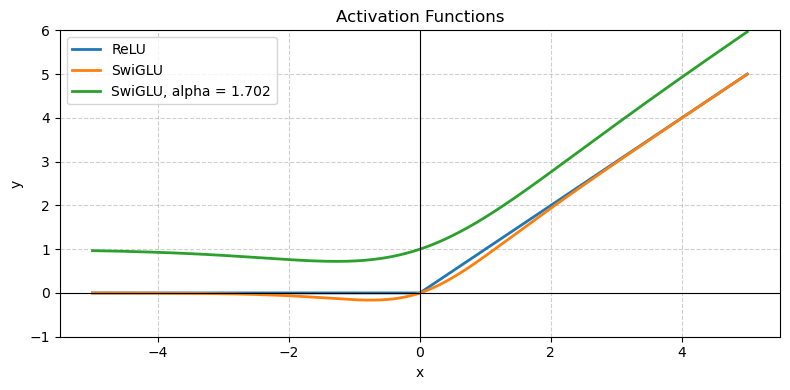

In [150]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. 定义激活函数
# -----------------------------
def relu(x):
    """ReLU 激活函数"""
    return np.maximum(0, x)

def swiglu(x, alpha = 1):
    """
    SwiGLU 激活函数：x · sigmoid(x)
    在一些文献里也写作 Swish(x) = x * sigmoid(x)
    """
    return x * (1 / (1 + np.exp(-alpha * x)))

# -----------------------------
# 2. 构造 x 数据
# -----------------------------
x = np.linspace(-5, 5, 400)

# -----------------------------
# 3. 计算 y 数据
# -----------------------------
y_relu   = relu(x)
y_swiglu = swiglu(x)
y_swiglu = swiglu(x, 1.702)
# y_swiglu_plus2 = swiglu(x) + 2

# -----------------------------
# 4. 绘图
# -----------------------------
plt.figure(figsize=(8, 4))
plt.plot(x, y_relu,   label='ReLU', lw=2)
plt.plot(x, y_swiglu, label='SwiGLU', lw=2)
plt.plot(x, y_swiglu_plus1, label='SwiGLU, alpha = 1.702', lw=2)
# plt.plot(x, y_swiglu_plus2, label='SwiGLU + 2', lw=2) 

plt.title('Activation Functions')
plt.xlabel('x')
plt.ylabel('y')

# 设置网格和坐标轴
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=0, color='k', linewidth=0.8)
plt.axvline(x=0, color='k', linewidth=0.8)
plt.ylim(-1, 6)

plt.legend()
# plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()